<a href="https://colab.research.google.com/github/adonaikidane/CC-Fraud/blob/main/ML_deep_learning_project_Adonai_Kidane.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd # library for data manip.
import numpy as np # library for numerical computations

In [ ]:
df = pd.read_csv('fraudDataset.csv')
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495.0,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1.325376e+09,36.011293,-82.048315,0.0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149.0,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1.325376e+09,49.159047,-118.186462,0.0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154.0,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1.325376e+09,43.150704,-112.154481,0.0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939.0,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1.325376e+09,47.034331,-112.561071,0.0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99.0,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1.325376e+09,38.674999,-78.632459,0.0


In [ ]:
df.shape

(42831, 23)

In [ ]:
df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

In [ ]:
df['is_fraud'].value_counts()

,count
is_fraud,
0.0,42433
1.0,397


0: non fradulent, 1: fradulent

In [ ]:
#calc null values
df.isnull().sum()

,0
Unnamed: 0,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0


In [ ]:
df.dropna(inplace=True)
df.isnull().sum()

,0
Unnamed: 0,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0


In [ ]:
#drop relevant columns
df.drop(['Unnamed: 0', 'cc_num', 'trans_num', 'first', 'last'], axis=1, inplace=True)
df.head()

,trans_date_trans_time,merchant,category,amt,gender,street,city,state,zip,lat,long,city_pop,job,dob,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495.0,"Psychologist, counselling",1988-03-09,1.325376e+09,36.011293,-82.048315,0.0
1,2019-01-01 00:00:44,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149.0,Special educational needs teacher,1978-06-21,1.325376e+09,49.159047,-118.186462,0.0
2,2019-01-01 00:00:51,fraud_Lind-Buckridge,entertainment,220.11,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154.0,Nature conservation officer,1962-01-19,1.325376e+09,43.150704,-112.154481,0.0
3,2019-01-01 00:01:16,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939.0,Patent attorney,1967-01-12,1.325376e+09,47.034331,-112.561071,0.0
4,2019-01-01 00:03:06,fraud_Keeling-Crist,misc_pos,41.96,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99.0,Dance movement psychotherapist,1986-03-28,1.325376e+09,38.674999,-78.632459,0.0


In [ ]:
import pandas as pd
df['dob'] = pd.to_datetime(df['dob'])
df['age'] = ((pd.to_datetime('today') - df['dob']).dt.days/365.25).astype(int)
df.drop(['dob'], axis=1, inplace=True)
df.head()

,trans_date_trans_time,merchant,category,amt,gender,street,city,state,zip,lat,long,city_pop,job,unix_time,merch_lat,merch_long,is_fraud,age
0,2019-01-01 00:00:18,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495.0,"Psychologist, counselling",1.325376e+09,36.011293,-82.048315,0.0,37
1,2019-01-01 00:00:44,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149.0,Special educational needs teacher,1.325376e+09,49.159047,-118.186462,0.0,47
2,2019-01-01 00:00:51,fraud_Lind-Buckridge,entertainment,220.11,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154.0,Nature conservation officer,1.325376e+09,43.150704,-112.154481,0.0,63
3,2019-01-01 00:01:16,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939.0,Patent attorney,1.325376e+09,47.034331,-112.561071,0.0,58
4,2019-01-01 00:03:06,fraud_Keeling-Crist,misc_pos,41.96,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99.0,Dance movement psychotherapist,1.325376e+09,38.674999,-78.632459,0.0,39


In [ ]:
#unix time to date
df['unix_time'] = df['unix_time'].astype(int)
df['unix_time'] = pd.to_datetime(df['unix_time'], unit='s')
df.head()

,trans_date_trans_time,merchant,category,amt,gender,street,city,state,zip,lat,long,city_pop,job,unix_time,merch_lat,merch_long,is_fraud,age
0,2019-01-01 00:00:18,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495.0,"Psychologist, counselling",2012-01-01 00:00:18,36.011293,-82.048315,0.0,37
1,2019-01-01 00:00:44,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149.0,Special educational needs teacher,2012-01-01 00:00:44,49.159047,-118.186462,0.0,47
2,2019-01-01 00:00:51,fraud_Lind-Buckridge,entertainment,220.11,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154.0,Nature conservation officer,2012-01-01 00:00:51,43.150704,-112.154481,0.0,63
3,2019-01-01 00:01:16,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939.0,Patent attorney,2012-01-01 00:01:16,47.034331,-112.561071,0.0,58
4,2019-01-01 00:03:06,fraud_Keeling-Crist,misc_pos,41.96,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99.0,Dance movement psychotherapist,2012-01-01 00:03:06,38.674999,-78.632459,0.0,39


In [ ]:
#target encoding for job
target_mean = df.groupby('job')['is_fraud'].mean()

#print(target_mean)
df['job_encoded'] = df['job'].map(target_mean)

#do target encoding for merchant
target_mean2 = df.groupby('merchant')['is_fraud'].mean()

#print(target_mean2)
df['merchant_encoded'] = df['merchant'].map(target_mean2)

df.drop(['job', 'merchant'], axis=1, inplace=True)
df.head()

,trans_date_trans_time,category,amt,gender,street,city,state,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,age,job_encoded,merchant_encoded
0,2019-01-01 00:00:18,misc_net,4.97,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495.0,2012-01-01 00:00:18,36.011293,-82.048315,0.0,37,0.0,0.018868
1,2019-01-01 00:00:44,grocery_pos,107.23,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149.0,2012-01-01 00:00:44,49.159047,-118.186462,0.0,47,0.0,0.000000
2,2019-01-01 00:00:51,entertainment,220.11,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154.0,2012-01-01 00:00:51,43.150704,-112.154481,0.0,63,0.0,0.000000
3,2019-01-01 00:01:16,gas_transport,45.00,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939.0,2012-01-01 00:01:16,47.034331,-112.561071,0.0,58,0.0,0.000000
4,2019-01-01 00:03:06,misc_pos,41.96,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99.0,2012-01-01 00:03:06,38.674999,-78.632459,0.0,39,0.0,0.000000


In [ ]:
#hot encodign for gender, category, w 0
df = pd.get_dummies(df, columns=['gender', 'category'], dtype=int)
df.head()

,trans_date_trans_time,amt,street,city,state,zip,lat,long,city_pop,unix_time,...,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel
0,2019-01-01 00:00:18,4.97,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495.0,2012-01-01 00:00:18,...,0,0,0,0,1,0,0,0,0,0
1,2019-01-01 00:00:44,107.23,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149.0,2012-01-01 00:00:44,...,1,0,0,0,0,0,0,0,0,0
2,2019-01-01 00:00:51,220.11,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154.0,2012-01-01 00:00:51,...,0,0,0,0,0,0,0,0,0,0
3,2019-01-01 00:01:16,45.00,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939.0,2012-01-01 00:01:16,...,0,0,0,0,0,0,0,0,0,0
4,2019-01-01 00:03:06,41.96,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99.0,2012-01-01 00:03:06,...,0,0,0,0,0,1,0,0,0,0


In [ ]:
#looking into location
df.drop(['lat', 'long', 'street', 'city'], axis=1, inplace=True)
df.head()

,trans_date_trans_time,amt,state,zip,city_pop,unix_time,merch_lat,merch_long,is_fraud,age,...,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel
0,2019-01-01 00:00:18,4.97,NC,28654,3495.0,2012-01-01 00:00:18,36.011293,-82.048315,0.0,37,...,0,0,0,0,1,0,0,0,0,0
1,2019-01-01 00:00:44,107.23,WA,99160,149.0,2012-01-01 00:00:44,49.159047,-118.186462,0.0,47,...,1,0,0,0,0,0,0,0,0,0
2,2019-01-01 00:00:51,220.11,ID,83252,4154.0,2012-01-01 00:00:51,43.150704,-112.154481,0.0,63,...,0,0,0,0,0,0,0,0,0,0
3,2019-01-01 00:01:16,45.00,MT,59632,1939.0,2012-01-01 00:01:16,47.034331,-112.561071,0.0,58,...,0,0,0,0,0,0,0,0,0,0
4,2019-01-01 00:03:06,41.96,VA,24433,99.0,2012-01-01 00:03:06,38.674999,-78.632459,0.0,39,...,0,0,0,0,0,1,0,0,0,0


In [ ]:
#encode zip coees
target_mean3 = df.groupby('zip')['is_fraud'].mean()

#print(target_mean3)
df['zip_encoded'] = df['zip'].map(target_mean3)

df.drop(['zip'], axis=1, inplace=True)
df.head()

,trans_date_trans_time,amt,state,city_pop,unix_time,merch_lat,merch_long,is_fraud,age,job_encoded,...,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel,zip_encoded
0,2019-01-01 00:00:18,4.97,NC,3495.0,2012-01-01 00:00:18,36.011293,-82.048315,0.0,37,0.0,...,0,0,0,1,0,0,0,0,0,0.0
1,2019-01-01 00:00:44,107.23,WA,149.0,2012-01-01 00:00:44,49.159047,-118.186462,0.0,47,0.0,...,0,0,0,0,0,0,0,0,0,0.0
2,2019-01-01 00:00:51,220.11,ID,4154.0,2012-01-01 00:00:51,43.150704,-112.154481,0.0,63,0.0,...,0,0,0,0,0,0,0,0,0,0.0
3,2019-01-01 00:01:16,45.00,MT,1939.0,2012-01-01 00:01:16,47.034331,-112.561071,0.0,58,0.0,...,0,0,0,0,0,0,0,0,0,0.0
4,2019-01-01 00:03:06,41.96,VA,99.0,2012-01-01 00:03:06,38.674999,-78.632459,0.0,39,0.0,...,0,0,0,0,1,0,0,0,0,0.0


In [ ]:
df.columns

Index(['trans_date_trans_time', 'amt', 'state', 'city_pop', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud', 'age', 'job_encoded',
       'merchant_encoded', 'gender_F', 'gender_M', 'category_entertainment',
       'category_food_dining', 'category_gas_transport',
       'category_grocery_net', 'category_grocery_pos',
       'category_health_fitness', 'category_home', 'category_kids_pets',
       'category_misc_net', 'category_misc_pos', 'category_personal_care',
       'category_shopping_net', 'category_shopping_pos', 'category_travel',
       'zip_encoded'],
      dtype='object')

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True)
)

(34264, 27) (8566, 27)
is_fraud
0.0    0.990719
1.0    0.009281
Name: proportion, dtype: float64
is_fraud
0.0    0.990777
1.0    0.009223
Name: proportion, dtype: float64


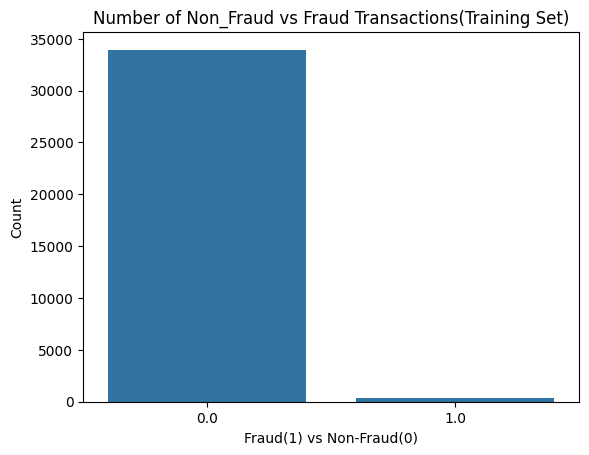

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x=y_train)
plt.title('Number of Non_Fraud vs Fraud Transactions(Training Set)')
plt.xlabel('Fraud(1) vs Non-Fraud(0)')
plt.ylabel('Count')
plt.show()


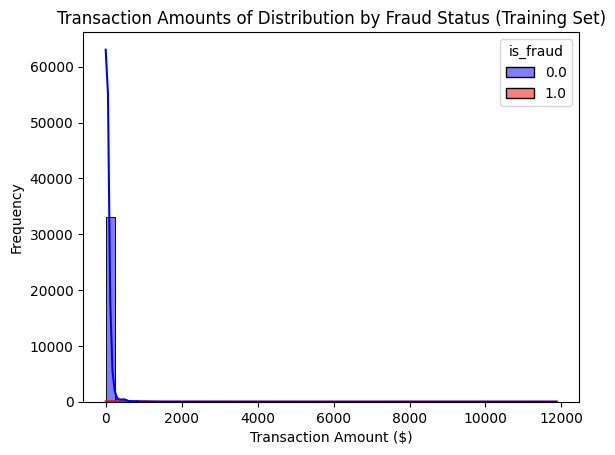

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(
    x=X_train['amt'],
    bins=50,
    hue=y_train,
    kde=True,
    palette=['blue', 'red'],
    alpha=0.5
)
plt.title('Transaction Amounts of Distribution by Fraud Status (Training Set)')
plt.xlabel('Transaction Amount ($)')
plt.ylabel('Frequency')
plt.show()

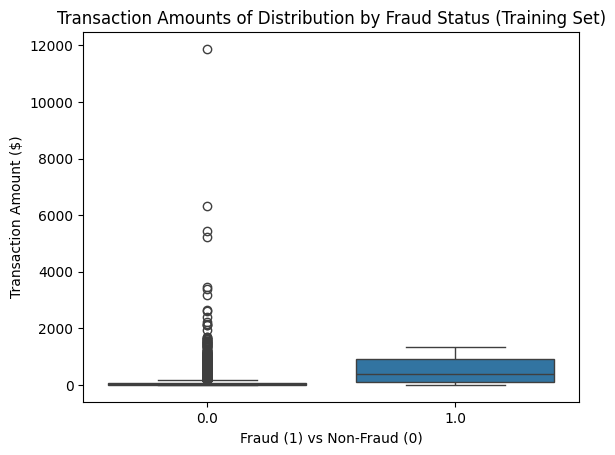

In [ ]:
sns.boxplot (x=y_train, y=X_train['amt'])
plt.title('Transaction Amounts of Distribution by Fraud Status (Training Set)')
plt.xlabel('Fraud (1) vs Non-Fraud (0)')
plt.ylabel('Transaction Amount ($)')
plt.show()

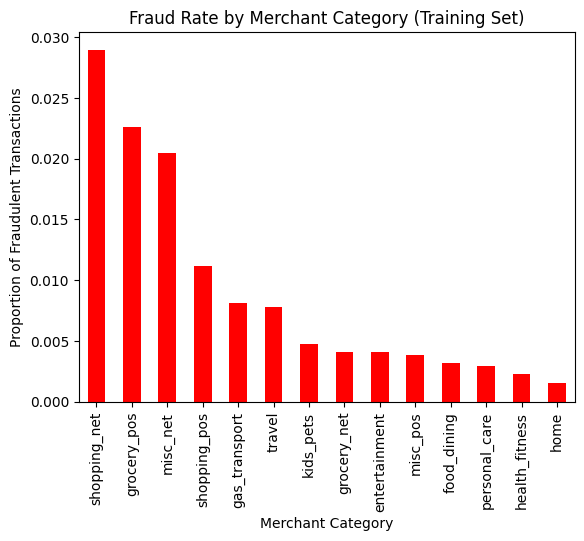

In [ ]:
category_columns = [col for col in X_train.columns if col.startswith('category_')]

fraud_rates = {}
for col in category_columns:
    category_name = col.replace('category_', '')
    # Calculate mean of is_fraud where the specific category column is 1
    fraud_rates[category_name] = y_train[X_train[col] == 1].mean()

fraud_rate_by_cat = pd.Series(fraud_rates).sort_values(ascending=False)
fraud_rate_by_cat.plot(kind='bar', color='red')
plt.title('Fraud Rate by Merchant Category (Training Set)')
plt.xlabel('Merchant Category')
plt.ylabel('Proportion of Fraudulent Transactions')
plt.show()

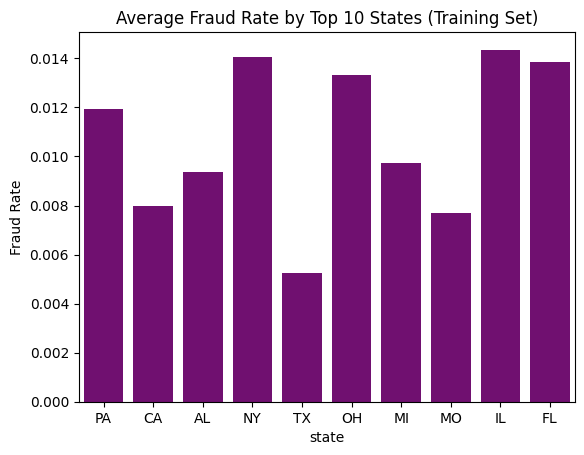

In [ ]:
fraud_by_state = X_train.copy()
fraud_by_state['is_fraud'] = y_train

top_states = fraud_by_state['state'].value_counts().head(10).index
fraud_by_state_top = fraud_by_state[fraud_by_state['state'].isin(top_states)]

sns.barplot(
    x='state',
    y='is_fraud',
    data=fraud_by_state_top,
    estimator=lambda x: sum(x)/len(x),
    errorbar=None,
    color='purple'
)
plt.title('Average Fraud Rate by Top 10 States (Training Set)')
plt.ylabel('Fraud Rate')
plt.show()

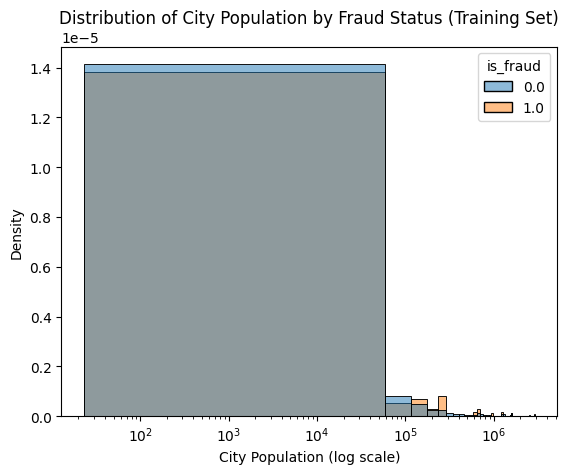

In [ ]:
sns.histplot(
    data=X_train.assign(is_fraud=y_train),
    x='city_pop',
    hue='is_fraud',
    bins=50,
    stat='density',
    common_norm=False

)
plt.xscale('log')
plt.title('Distribution of City Population by Fraud Status (Training Set)')
plt.xlabel('City Population (log scale)')
plt.ylabel('Density')
plt.show()

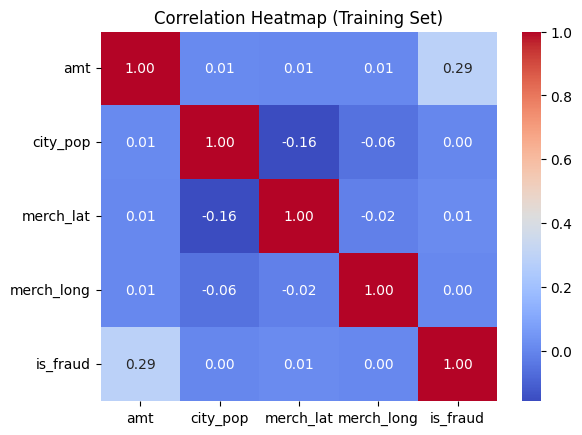

In [ ]:
num_cols = ['amt', 'city_pop', 'merch_lat', 'merch_long']
corr_df = X_train[num_cols].copy()
corr_df['is_fraud'] = y_train

sns.heatmap(corr_df.corr(), annot=True,  cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap (Training Set)')
plt.show()

**11**/13

In [ ]:
\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\***Complete the following below by udating from frameworks***

In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv('fraudDataset.csv')
df.head()


In [ ]:
import pandas as pd
df_clean = df.copy()


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
import pandas as pd

In [ ]:
from sklearn.linear_model import LogisticRegression
